# California Housing Price Prediction

This project explores Linear Regression, Polynomial Regression, and Ridge Regularization.
We analyze model performance using RMSE, R² score, cross-validation, and learning curves.

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("camnugent/california-housing-prices")

print("Path to dataset files:", path)

d:\SOMETHING\california_housing\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\HP\.cache\kagglehub\datasets\camnugent\california-housing-prices\versions\1


In [3]:
import pandas as pd

new_path = "D:/SOMETHING/california_housing/dataset/housing.csv"
df = pd.read_csv(new_path)

In [4]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


## Data Preparation

We load the dataset, perform train-test splitting, and create stratified samples to preserve data distribution.

In [8]:
import numpy as np

df["income_cat"] = pd.cut(
    df["median_income"],
    bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
    labels=[1, 2, 3, 4, 5]
)

In [9]:
from sklearn.model_selection import train_test_split

strat_train_set, strat_test_set = train_test_split(
    df, 
    test_size=0.2, 
    stratify=df["income_cat"], 
    random_state=42
)

In [11]:
for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

In [12]:
strat_test_set.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
5241,-118.39,34.12,29.0,6447.0,1012.0,2184.0,960.0,8.2816,500001.0,<1H OCEAN
17352,-120.42,34.89,24.0,2020.0,307.0,855.0,283.0,5.0099,162500.0,<1H OCEAN
3505,-118.45,34.25,36.0,1453.0,270.0,808.0,275.0,4.3839,204600.0,<1H OCEAN
7777,-118.10,33.91,35.0,1653.0,325.0,1072.0,301.0,3.2708,159700.0,<1H OCEAN
14155,-117.07,32.77,38.0,3779.0,614.0,1495.0,614.0,4.3529,184000.0,NEAR OCEAN


In [13]:
X_train = strat_train_set.drop("median_house_value", axis=1)
y_train = strat_train_set["median_house_value"].copy()

X_test = strat_test_set.drop("median_house_value", axis=1)
y_test = strat_test_set["median_house_value"].copy()

In [16]:
X_train.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
12655,-121.46,38.52,29.0,3873.0,797.0,2237.0,706.0,2.1736,INLAND
15502,-117.23,33.09,7.0,5320.0,855.0,2015.0,768.0,6.3373,NEAR OCEAN
2908,-119.04,35.37,44.0,1618.0,310.0,667.0,300.0,2.8750,INLAND
14053,-117.13,32.75,24.0,1877.0,519.0,898.0,483.0,2.2264,NEAR OCEAN
20496,-118.70,34.28,27.0,3536.0,646.0,1837.0,580.0,4.4964,<1H OCEAN


## Feature Engineering

We preprocess the dataset using:
- Handling missing values (imputation)
- Feature scaling (StandardScaler)
- Encoding categorical variables (OneHotEncoding)

In [22]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

num_attri = list(X_train.drop("ocean_proximity", axis=1))
cat_attri = ["ocean_proximity"] 

full_pipeline = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), num_attri),

    ("cat", OneHotEncoder(), cat_attri)
])



In [23]:
X_train_prepared = full_pipeline.fit_transform(X_train)
X_test_prepared = full_pipeline.transform(X_test)

## Polynomial Feature Expansion

We expand features to capture non-linear relationships using polynomial transformations.
This allows linear models to learn more complex patterns.

In [80]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(3, include_bias=False)

X_train_poly = poly.fit_transform(X_train_prepared)
X_test_poly = poly.transform(X_test_prepared)

# Implementing own Polynomial Ridge Rgression Model
We implement Linear Regression from scratch using the Normal Equation:
θ = (XᵀX)⁻¹ Xᵀy

This helps us understand the mathematical foundation of linear models.

We introduce Ridge Regression to reduce overfitting by penalizing large weights.
The regularization strength is controlled by the parameter alpha

In [81]:
from sklearn.base import BaseEstimator, RegressorMixin

class Ridge_Regression_model(BaseEstimator, RegressorMixin):
    def __init__(self, alpha=1.0):
        self.alpha = alpha
        self.theta = None

    def fit(self, X, y):
        X = np.asanyarray(X)
        y = np.asarray(y).reshape(-1, 1)

        X_b = np.c_[np.ones((X.shape[0], 1)), X]

        n_features = X_b.shape[1]

        # identity matrix
        I = np.eye(n_features)
        I[0, 0] = 0  

        # ridge equation
        self.theta = np.linalg.pinv(X_b.T @ X_b + self.alpha * I) @ X_b.T @ y
        return self
    
    def predict(self, X):
        X = np.asanyarray(X)

        X_b = np.c_[np.ones((X.shape[0], 1)), X]
        return (X_b @ self.theta).ravel()



In [82]:
model = Ridge_Regression_model(alpha=2000)

model.fit(X_train_poly, y_train)
y_pred = model.predict(X_test_poly)

## Model Evaluation (RMSE)

We evaluate model performance using Root Mean Squared Error (RMSE),
which measures the average prediction error.

## Cross Validation

We use k-fold cross-validation to obtain a reliable estimate of model performance
and reduce dependence on a single train-test split.

In [83]:
from sklearn.model_selection import cross_val_score

alphas = [0.01, 0.1, 1, 5, 10, 20, 50, 100, 200, 500, 1000, 2000]

for a in alphas:
    model = Ridge_Regression_model(alpha=a)
    
    scores = cross_val_score(
        model,
        X_train_poly,
        y_train,
        scoring="neg_mean_squared_error",
        cv=5
    )
    
    rmse = np.sqrt(-scores)
    print(f"alpha={a}, RMSE={rmse.mean()}")

alpha=0.01, RMSE=145602.8633007593
alpha=0.1, RMSE=143066.0561149062
alpha=1, RMSE=138244.84272335138
alpha=5, RMSE=136345.64684487873
alpha=10, RMSE=134940.0034431634
alpha=20, RMSE=132444.79292241213
alpha=50, RMSE=126973.52208317441
alpha=100, RMSE=120409.89721934083
alpha=200, RMSE=110367.30622891735
alpha=500, RMSE=90478.07329172269
alpha=1000, RMSE=73148.84969037099
alpha=2000, RMSE=64558.603782005724


## Hyperparameter Tuning

We tune the regularization parameter alpha using cross-validation and grid search
to find the optimal balance between bias and variance.

In [84]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "alpha": [0.01, 0.1, 1, 5, 10, 15, 20, 50, 100, 200, 500, 1000, 2000]
}

grid = GridSearchCV(
    Ridge_Regression_model(),
    param_grid,
    scoring="neg_mean_squared_error",
    cv=5
)

grid.fit(X_train_poly, y_train)

print("Best alpha:", grid.best_params_)

Best alpha: {'alpha': 2000}


## Learning Curves

Learning curves show how model performance changes with training size.
They help diagnose:
- Underfitting (high bias)
- Overfitting (high variance)

In [85]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt

train_sizes, train_scores, val_scores = learning_curve(
    model,
    X_train_poly,
    y_train,
    scoring="neg_mean_squared_error",
    cv=5
)

In [86]:
train_rmse = np.sqrt(-train_scores).mean(axis=1)
val_rmse = np.sqrt(-val_scores).mean(axis=1)

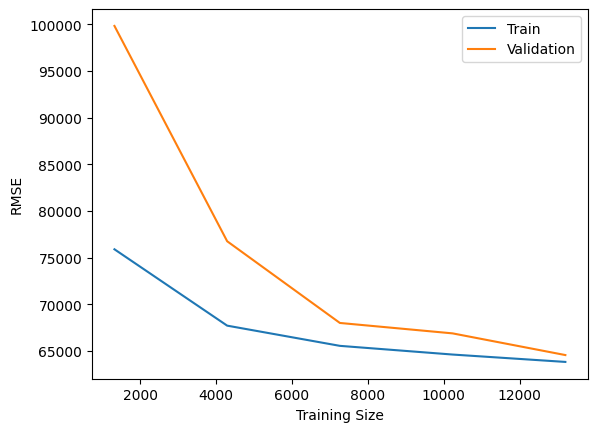

In [87]:
plt.plot(train_sizes, train_rmse, label="Train")
plt.plot(train_sizes, val_rmse, label="Validation")

plt.xlabel("Training Size")
plt.ylabel("RMSE")
plt.legend()
plt.show()

## R² Score

R² measures how well the model explains the variance in the data.
Higher values indicate better performance.

For degree 3 and alpha = 2000 the R2 score is :

In [88]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("R² score:", r2)

R² score: 0.577647068058626


For degree 1 and alpha = 20 the R2 score is :

In [92]:
model = Ridge_Regression_model(alpha=20)

poly = PolynomialFeatures(1, include_bias=False)

X_train_poly = poly.fit_transform(X_train_prepared)
X_test_poly = poly.transform(X_test_prepared)

model.fit(X_train_poly, y_train)
y_pred = model.predict(X_test_poly)

r2 = r2_score(y_test, y_pred)
print("R² score:", r2)

R² score: 0.6505300090236983


## Polynomial Degree Comparison with Regularization

We train polynomial regression models with different degrees and use the best regularization strength (alpha) for each model.

Chosen hyperparameters:
- Degree 1 → alpha = 20
- Degree 2 → alpha = 500
- Degree 3 → alpha = 2000

This allows a fair comparison between models by controlling overfitting appropriately.

We evaluate each model using cross-validation and learning curves to study the bias-variance tradeoff.

In [93]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score
import numpy as np

degrees = [1, 2, 3]
alphas = [20, 500, 2000]

for d, a in zip(degrees, alphas):
    poly = PolynomialFeatures(degree=d, include_bias=False)

    X_poly = poly.fit_transform(X_train_prepared)

    model = Ridge(alpha=a)

    scores = cross_val_score(
        model,
        X_poly,
        y_train,
        scoring="neg_mean_squared_error",
        cv=5
    )

    rmse = np.sqrt(-scores)
    print(f"Degree {d} (alpha={a}): RMSE = {rmse.mean():.2f}")

Degree 1 (alpha=20): RMSE = 69216.27
Degree 2 (alpha=500): RMSE = 71079.63
Degree 3 (alpha=2000): RMSE = 64558.60


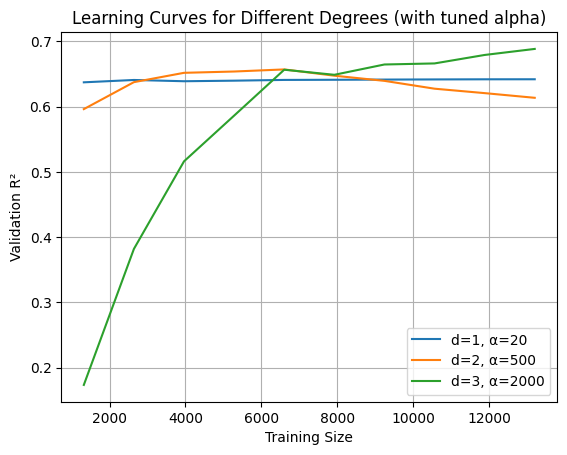

In [94]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt

degrees = [1, 2, 3]
alphas = [20, 500, 2000]

for d, a in zip(degrees, alphas):
    poly = PolynomialFeatures(degree=d, include_bias=False)
    X_poly = poly.fit_transform(X_train_prepared)

    model = Ridge_Regression_model(alpha=a)

    train_sizes, train_scores, val_scores = learning_curve(
        model,
        X_poly,
        y_train,
        scoring="r2",
        cv=5,
        train_sizes=np.linspace(0.1, 1.0, 10)
    )

    plt.plot(train_sizes, val_scores.mean(axis=1), label=f"d={d}, α={a}")

plt.xlabel("Training Size")
plt.ylabel("Validation R²")
plt.title("Learning Curves for Different Degrees (with tuned alpha)")
plt.legend()
plt.grid()
plt.show()

## Final Insights

This study explored polynomial regression models of different degrees with Ridge regularization on the California Housing dataset.

### Key Observations:

- **Degree 1 (Linear Model)**:
  - Achieves the highest R² score (~0.65) on the test set.
  - Shows stable and consistent performance.
  - Indicates **low variance but higher bias (underfitting)**.

- **Degree 2 Model**:
  - Slightly worse RMSE and R² compared to Degree 1.
  - Does not significantly improve model performance.
  - Suggests that moderate complexity alone is insufficient.

- **Degree 3 Model (with strong regularization)**:
  - Achieves the **lowest RMSE**, indicating lower average prediction error.
  - However, has a **lower R² score (~0.57)** on the test set.
  - Learning curves show improvement with more data but still exhibit instability.
  - Indicates **higher variance and sensitivity despite regularization**.

### Important Insight:

Although Degree 3 reduces absolute error (RMSE), it does not explain the variance in the data as effectively as Degree 1.  
This highlights that **lower RMSE does not always imply better generalization**.

### Bias-Variance Tradeoff:

- Degree 1 → High Bias, Low Variance  
- Degree 3 → Low Bias, High Variance  
- Degree 2 → Intermediate but not optimal  

### Final Conclusion:

The **Degree 1 model with Ridge regularization provides the best overall generalization performance** for this dataset.

This experiment demonstrates:
- The importance of balancing model complexity and regularization
- The need to evaluate models using multiple metrics (RMSE and R²)
- That increasing model complexity does not always lead to better performance
